Otsu threshold value: 101.0


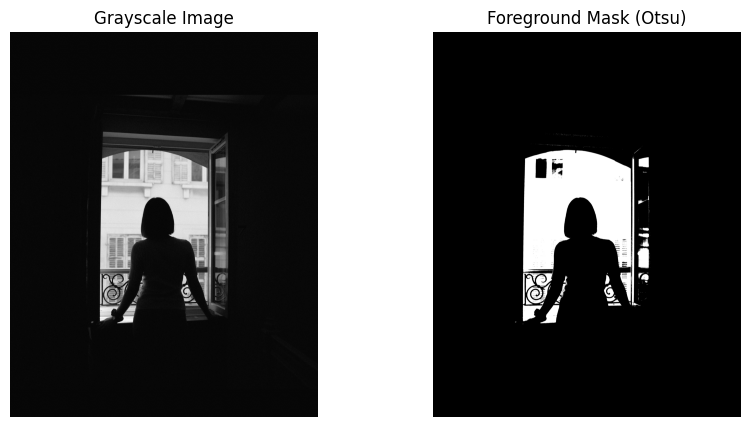

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


#load the image in grayscale mode
f = cv.imread('/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 01/ronak-valobobhai-6YzA45_b2vA-unsplash.jpg',cv.IMREAD_GRAYSCALE)
assert f is not None


# Apply Otsu's thresholding
thresh_val, mask = cv.threshold(f, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

print("Otsu threshold value:", thresh_val)

# Show results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Grayscale Image")
plt.imshow(f, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Foreground Mask (Otsu)")
plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()


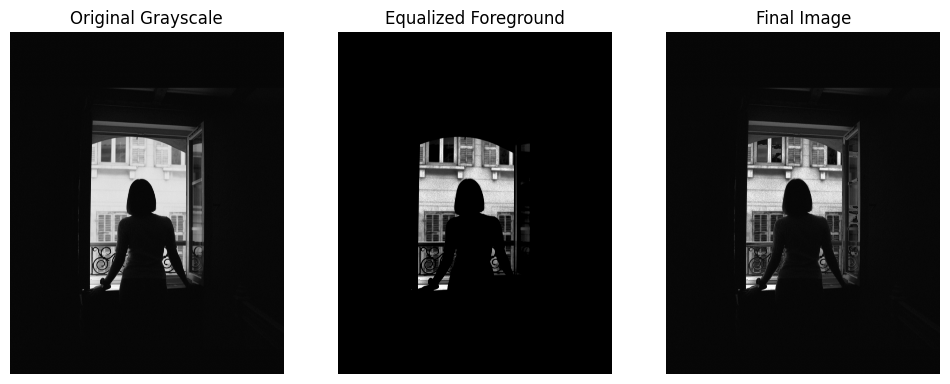

In [7]:
# Apply histogram equalization only to foreground pixels
foreground = cv.bitwise_and(f, f, mask=mask)
equalized_foreground = cv.equalizeHist(foreground)

# Combine equalized foreground with background (unchanged)
background = cv.bitwise_and(f, f, mask=cv.bitwise_not(mask))
result = cv.add(equalized_foreground, background)

# Show results
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title("Original Grayscale")
plt.imshow(f, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Equalized Foreground")
plt.imshow(equalized_foreground, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Final Image")
plt.imshow(result, cmap='gray')
plt.axis("off")
plt.show()
